<a href="https://colab.research.google.com/github/InfiniteLobster/CDA-case1/blob/main/case_workspace.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [17]:
!pip install xgboost joblib -q

In [18]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [19]:
# Import libraries
import plotly.express as px
import plotly.graph_objects as go
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import Lasso, Ridge, ElasticNet, LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.decomposition import PCA

%matplotlib inline
sns.set_style("whitegrid")

In [20]:
import warnings
warnings.filterwarnings('ignore')

# Set up styling for matplotlib (for report)
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

In [21]:
# Load datasets
train_df = pd.read_csv("/content/drive/MyDrive/case-data/case1Data.csv")
xnew_df = pd.read_csv("/content/drive/MyDrive/case-data/case1Data_Xnew.csv")

print("Training data shape:", train_df.shape)
print("New data shape:", xnew_df.shape)

Training data shape: (100, 101)
New data shape: (1000, 100)


In [22]:
# Split features and target
y_train = train_df.iloc[:,0]
X_train = train_df.iloc[:,1:]
X_new = xnew_df

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

print(X_train.head())
print(y_train.head())

X_train shape: (100, 100)
y_train shape: (100,)
       x_01       x_02      x_03       x_04       x_05      x_06       x_07  \
0  6.359019 -13.367120 -2.483750  -6.641891  11.733539       NaN -17.085361   
1  3.873664  -8.470389 -3.055012        NaN  11.420983  1.822330 -13.694100   
2  5.275824 -12.070531 -1.366168  -4.819100  10.721527 -5.125992 -17.476865   
3  4.430110  -4.467975 -0.730736 -10.047104  11.498539 -2.870260 -14.033012   
4  3.116458  -8.518713 -6.796050        NaN   7.646285 -3.118309 -13.102567   

        x_08       x_09       x_10  ...       x_91       x_92      x_93  \
0  22.194764  16.827888 -10.367142  ... -10.200888   3.980048 -4.433274   
1  22.738654  20.307503  -2.859097  ...  -9.740207        NaN -2.629314   
2        NaN  15.963889  -3.257940  ... -14.501970  10.054005       NaN   
3  18.225190  10.409488  -5.616061  ... -11.086963   2.019726 -8.531959   
4  22.801217  16.680208  -3.357765  ...  -9.117422   6.627601 -2.805531   

       x_94       x_95  C_

In [23]:
# Identify categorical columns
cat_cols = [col for col in X_train.columns if col.startswith("C_")]
num_cols = [col for col in X_train.columns if not col.startswith("C_")]

print("Number of numerical columns:", len(num_cols))
print("Number of categorical columns:", len(cat_cols))
print("Categorical columns:",cat_cols)

Number of numerical columns: 95
Number of categorical columns: 5
Categorical columns: ['C_01', 'C_02', 'C_03', 'C_04', 'C_05']



1. Creating target variable distribution plot...


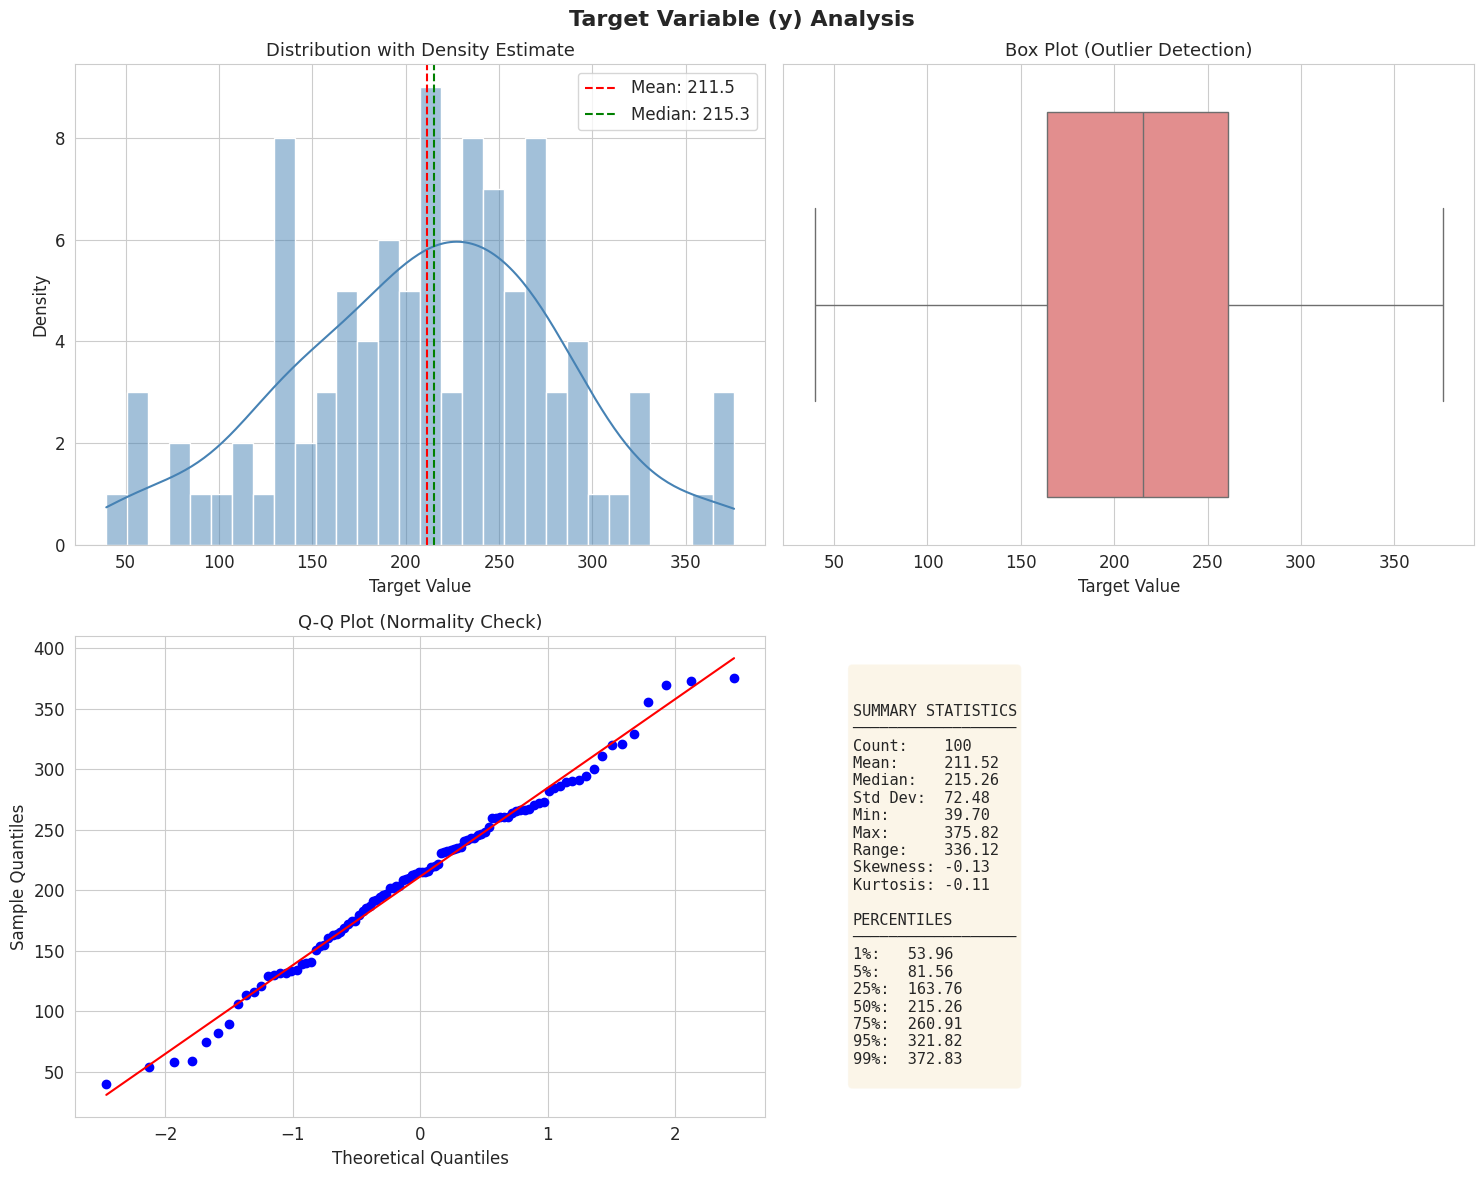

In [24]:
print("\n1. Creating target variable distribution plot...")

fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Target Variable (y) Analysis', fontsize=16, fontweight='bold')

# Histogram with KDE
sns.histplot(y_train, bins=30, kde=True, ax=axes[0, 0], color='steelblue')
axes[0, 0].set_title('Distribution with Density Estimate', fontsize=13)
axes[0, 0].set_xlabel('Target Value')
axes[0, 0].set_ylabel('Density')
axes[0, 0].axvline(y_train.mean(), color='red', linestyle='--', label=f'Mean: {y_train.mean():.1f}')
axes[0, 0].axvline(y_train.median(), color='green', linestyle='--', label=f'Median: {y_train.median():.1f}')
axes[0, 0].legend()

# Box plot
sns.boxplot(x=y_train, ax=axes[0, 1], color='lightcoral')
axes[0, 1].set_title('Box Plot (Outlier Detection)', fontsize=13)
axes[0, 1].set_xlabel('Target Value')

# QQ plot (normality check)
from scipy import stats
stats.probplot(y_train, dist="norm", plot=axes[1, 0])
axes[1, 0].set_title('Q-Q Plot (Normality Check)', fontsize=13)
axes[1, 0].set_xlabel('Theoretical Quantiles')
axes[1, 0].set_ylabel('Sample Quantiles')

# Summary statistics table
axes[1, 1].axis('off')
stats_text = f"""

SUMMARY STATISTICS
──────────────────
Count:    {len(y_train)}
Mean:     {y_train.mean():.2f}
Median:   {y_train.median():.2f}
Std Dev:  {y_train.std():.2f}
Min:      {y_train.min():.2f}
Max:      {y_train.max():.2f}
Range:    {y_train.max() - y_train.min():.2f}
Skewness: {y_train.skew():.2f}
Kurtosis: {y_train.kurtosis():.2f}

PERCENTILES
──────────────────
1%:   {y_train.quantile(0.01):.2f}
5%:   {y_train.quantile(0.05):.2f}
25%:  {y_train.quantile(0.25):.2f}
50%:  {y_train.quantile(0.50):.2f}
75%:  {y_train.quantile(0.75):.2f}
95%:  {y_train.quantile(0.95):.2f}
99%:  {y_train.quantile(0.99):.2f}
"""
axes[1, 1].text(0.1, 0.5, stats_text, fontsize=11,
                verticalalignment='center', fontfamily='monospace',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

plt.tight_layout()
plt.savefig('target_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

In [25]:
print(X_new.shape)

(1000, 100)



2. Creating categorical variables visualization...


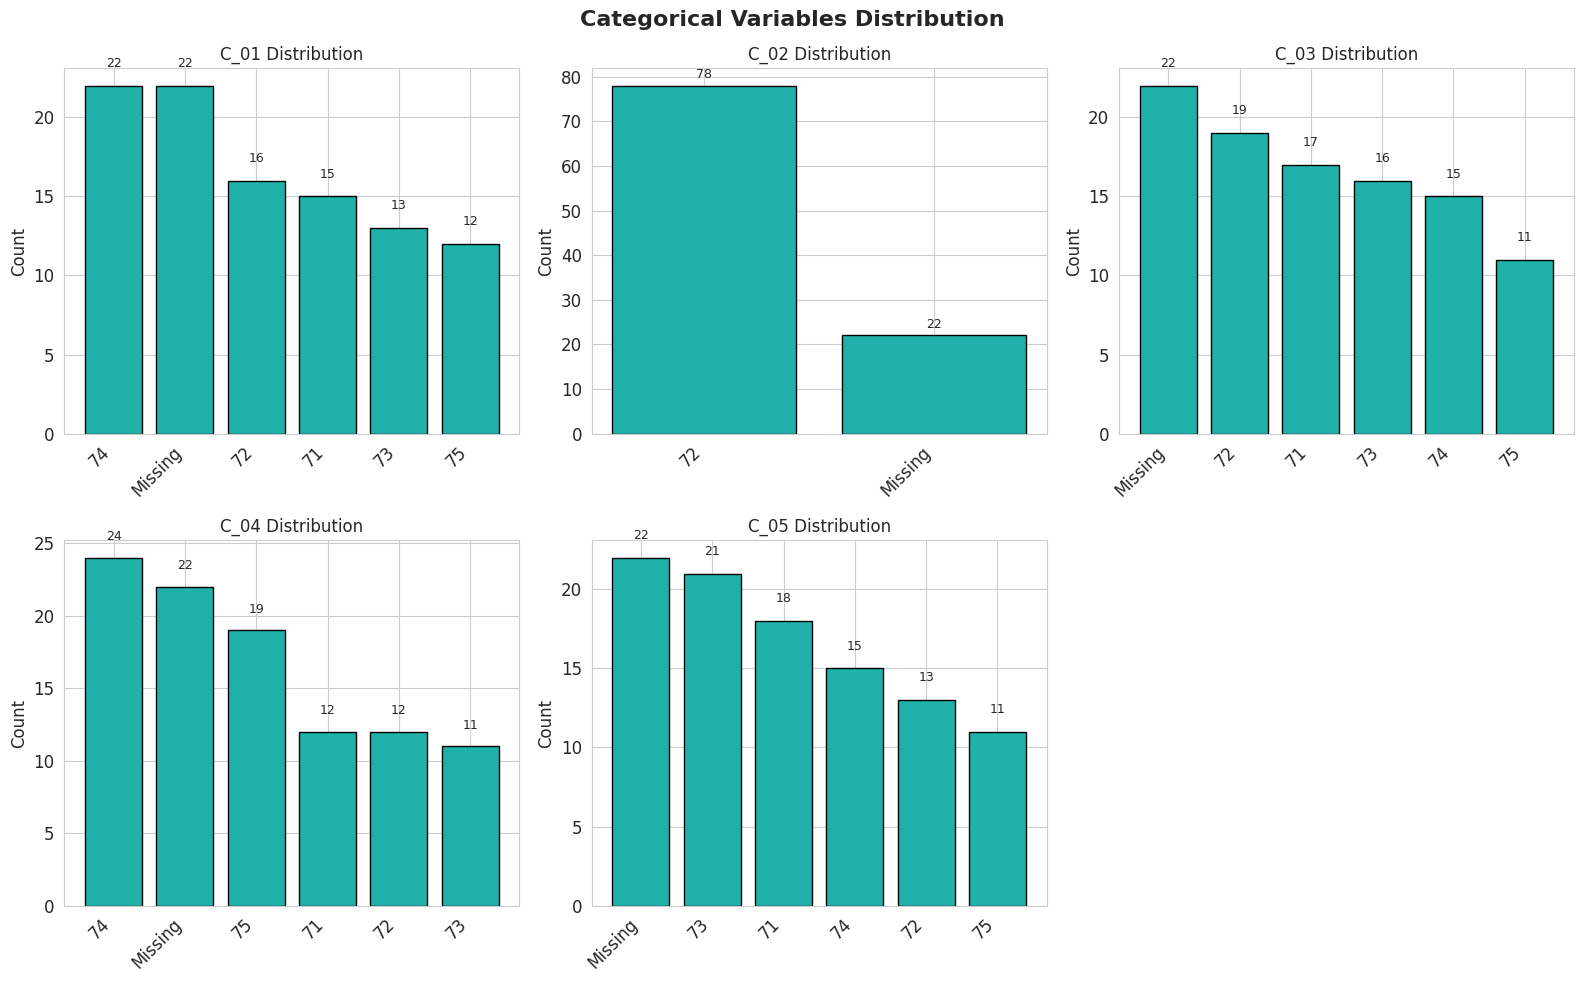

In [26]:
# Categorical variable visualization
print("\n2. Creating categorical variables visualization...")

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Categorical Variables Distribution', fontsize=16, fontweight='bold')
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    if i < len(axes):
        # Get value counts including NaN
        counts = X_train[col].value_counts(dropna=False)
        # Rename NaN for better display
        counts.index = ['Missing' if pd.isna(x) else f'{int(x)}' for x in counts.index]

        # Create bar plot
        bars = axes[i].bar(range(len(counts)), counts.values, color='lightseagreen', edgecolor='black')
        axes[i].set_xticks(range(len(counts)))
        axes[i].set_xticklabels(counts.index, rotation=45, ha='right')
        axes[i].set_title(f'{col} Distribution', fontsize=12)
        axes[i].set_ylabel('Count')

        # Add value labels
        for bar, val in zip(bars, counts.values):
            axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                        f'{val}', ha='center', va='bottom', fontsize=9)

# Hide unused subplot
if len(cat_cols) < 6:
    axes[5].set_visible(False)

plt.tight_layout()
plt.savefig('categorical_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

In [42]:
# Identifying problematic features

# Track which columns to drop
cat_cols_to_drop = []
num_cols_to_drop = []

# Step 1: Check categorical columns - CRITICAL for C_02
print("\n1. ANALYZING CATEGORICAL VARIABLES:")

for col in cat_cols:
    value_counts = X_train[col].value_counts(dropna=False)
    print(f"\n{col}:")
    print(f"   Unique values: {len(value_counts)}")
    for val, count in value_counts.items():
        val_display = 'Missing' if pd.isna(val) else f'{int(val)}'
        print(f"{val_display}: {count}")

    # CRITICAL CHECK: After imputation, what will happen?
    # Get the most frequent non-missing value
    non_missing_counts = X_train[col].value_counts(dropna=True)
    if len(non_missing_counts) > 0:
        most_frequent = non_missing_counts.index[0]
        most_frequent_count = non_missing_counts.iloc[0]
        missing_count = X_train[col].isnull().sum()

        # If most_frequent + missing = ALL rows, it becomes constant after imputation
        if most_frequent_count + missing_count == len(X_train):
            print(f"WARNING: {col} will become constant after imputation!")
            print(f"Most frequent value {int(most_frequent)} appears in {most_frequent_count} rows")
            print(f"Missing values: {missing_count}")
            print(f"After imputation: all {len(X_train)} rows become {int(most_frequent)}")
            cat_cols_to_drop.append(col)

# Step 2: Check numeric columns
print("\n2. ANALYZING NUMERIC FEATURES:")

for col in num_cols:
    non_nan_values = X_train[col].dropna()
    if len(non_nan_values) > 0:
        if non_nan_values.nunique() == 1:
            print(f"{col}: all non-missing values are the same")
            num_cols_to_drop.append(col)

if not num_cols_to_drop:
    print("No numeric features with constant values found.")

# Step 3: Remove problematic columns
print("\n3. REMOVING PROBLEMATIC FEATURES:")

if cat_cols_to_drop:
    print(f"Dropping categorical columns: {cat_cols_to_drop}")
    cat_cols = [col for col in cat_cols if col not in cat_cols_to_drop]
else:
    print("No problematic categorical columns found.")

if num_cols_to_drop:
    print(f"Dropping numeric columns: {num_cols_to_drop}")
    num_cols = [col for col in num_cols if col not in num_cols_to_drop]
else:
    print("No problematic numeric columns found.")

print(f"\n Remaining features:")
print(f"   Numeric: {len(num_cols)}")
print(f"   Categorical: {len(cat_cols)}")


1. ANALYZING CATEGORICAL VARIABLES:

C_01:
   Unique values: 6
74: 22
Missing: 22
72: 16
71: 15
73: 13
75: 12

C_02:
   Unique values: 2
72: 78
Missing: 22
Most frequent value 72 appears in 78 rows
Missing values: 22
After imputation: all 100 rows become 72

C_03:
   Unique values: 6
Missing: 22
72: 19
71: 17
73: 16
74: 15
75: 11

C_04:
   Unique values: 6
74: 24
Missing: 22
75: 19
71: 12
72: 12
73: 11

C_05:
   Unique values: 6
Missing: 22
73: 21
71: 18
74: 15
72: 13
75: 11

2. ANALYZING NUMERIC FEATURES:
No numeric features with constant values found.

3. REMOVING PROBLEMATIC FEATURES:
Dropping categorical columns: ['C_02']
No problematic numeric columns found.

 Remaining features:
   Numeric: 95
   Categorical: 4


In [43]:
# Feature type analysis
binary_cols = [col for col in cat_cols if X_train[col].nunique() == 2]
multi_cols = [col for col in cat_cols if X_train[col].nunique() > 2]

print("Binary categorical features:", len(binary_cols))
print("Multi-category features:", len(multi_cols))


# Positive vs mixed features
positive_only = [col for col in num_cols if (X_train[col] >= 0).all()]
mixed = [col for col in num_cols if not (X_train[col] >= 0).all()]

print("Positive-only features:", len(positive_only))
print("Mixed (+/-) features:", len(mixed))

Binary categorical features: 0
Multi-category features: 4
Positive-only features: 0
Mixed (+/-) features: 95


In [44]:
# After running the fixed CELL 6 and CELL 7, check the new shape
X_scaled_new = preprocessor_scaled.fit_transform(X_train)
print(f"New shape after removing C_02: {X_scaled_new.shape}")

New shape after removing C_02: (100, 116)


In [46]:
# Removing C_02
cat_cols_to_drop = ['C_02']

# Remove from cat_cols list
original_cat_count = len(cat_cols)
cat_cols = [col for col in cat_cols if col not in cat_cols_to_drop]

print(f"Original categorical columns: {original_cat_count}")
print(f"Categorical columns after removal: {len(cat_cols)}")
print(f"Removed: {cat_cols_to_drop}")

# Verify C_02 is gone
print(f"\nRemaining categorical columns: {cat_cols}")

Original categorical columns: 4
Categorical columns after removal: 4
Removed: ['C_02']

Remaining categorical columns: ['C_01', 'C_03', 'C_04', 'C_05']


In [47]:
# Create preprocessing pipelines

# Numeric preprocessing (scaled)
numeric_scaled = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical preprocessing
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# Preprocessor for scaled models (Lasso, ridge, elastic net and PCR)
preprocessor_scaled = ColumnTransformer([
    ("num", numeric_scaled, num_cols),
    ("cat", categorical_pipeline, cat_cols)
])

# Preprocessor for random forest (no scaling)
numeric_unscaled = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

preprocessor_unscaled = ColumnTransformer([
    ("num", numeric_unscaled, num_cols),
    ("cat", categorical_pipeline, cat_cols)
])

In [48]:
# Transform data and check for constants
X_scaled = preprocessor_scaled.fit_transform(X_train)
print(f"Transformed data shape: {X_scaled.shape}")

# Check for constant columns
preprocessed_df = pd.DataFrame(X_scaled)
constant_cols = [i for i in range(preprocessed_df.shape[1])
                 if preprocessed_df.iloc[:, i].std() < 1e-10]

print(f"Constant columns found: {len(constant_cols)}")

if len(constant_cols) > 0:
    print(f"Constant columns at indices: {constant_cols[:5]}")

    # Identify which feature caused this
    feature_names = num_cols.copy()
    encoder = preprocessor_scaled.named_transformers_['cat'].named_steps['encoder']
    cat_feature_names = encoder.get_feature_names_out(cat_cols)
    feature_names.extend(cat_feature_names)

    for idx in constant_cols[:3]:
        print(f"   Index {idx}: {feature_names[idx]}")
else:
    print("No constant columns detected!")

Transformed data shape: (100, 115)
Constant columns found: 0
No constant columns detected!



3. Creating missing data visualization...


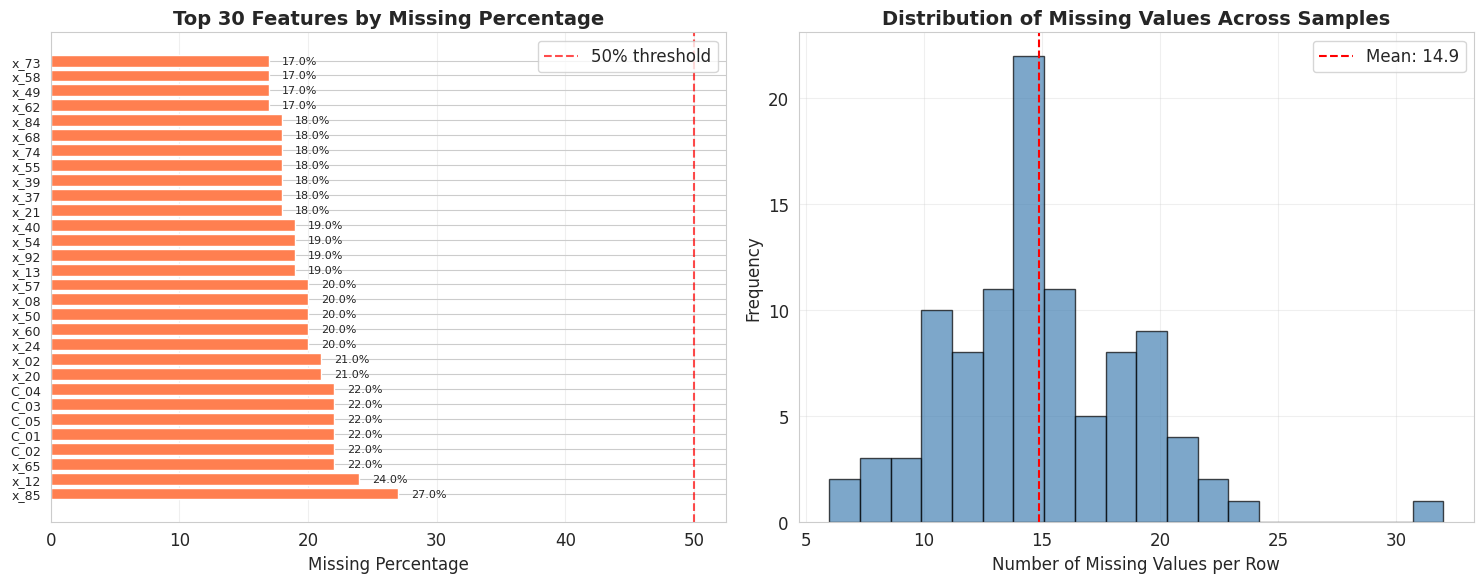

In [49]:
# Missing data pattern visualization
print("\n3. Creating missing data visualization...")

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Missing by feature
missing_count = X_train.isnull().sum()
missing_percent = (missing_count / len(X_train)) * 100
missing_df = pd.DataFrame({
    'Feature': missing_count.index,
    'Missing %': missing_percent.values
}).sort_values('Missing %', ascending=False).head(30)  # Top 30

ax1 = axes[0]
bars = ax1.barh(range(len(missing_df)), missing_df['Missing %'].values, color='coral')
ax1.set_yticks(range(len(missing_df)))
ax1.set_yticklabels(missing_df['Feature'].values, fontsize=9)
ax1.set_xlabel('Missing Percentage')
ax1.set_title('Top 30 Features by Missing Percentage', fontweight='bold')
ax1.axvline(50, color='red', linestyle='--', alpha=0.7, label='50% threshold')
ax1.legend()
ax1.grid(True, alpha=0.3, axis='x')

# Add value labels
for i, (bar, val) in enumerate(zip(bars, missing_df['Missing %'].values)):
    ax1.text(val + 1, i, f'{val:.1f}%', va='center', fontsize=8)

# Missing by sample
row_missing = X_train.isnull().sum(axis=1)
ax2 = axes[1]
ax2.hist(row_missing, bins=20, edgecolor='black', color='steelblue', alpha=0.7)
ax2.set_xlabel('Number of Missing Values per Row')
ax2.set_ylabel('Frequency')
ax2.set_title('Distribution of Missing Values Across Samples', fontweight='bold')
ax2.axvline(row_missing.mean(), color='red', linestyle='--',
            label=f'Mean: {row_missing.mean():.1f}')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('missing_data_patterns.png', dpi=300, bbox_inches='tight')
plt.show()


4. Creating PCA analysis visualization...


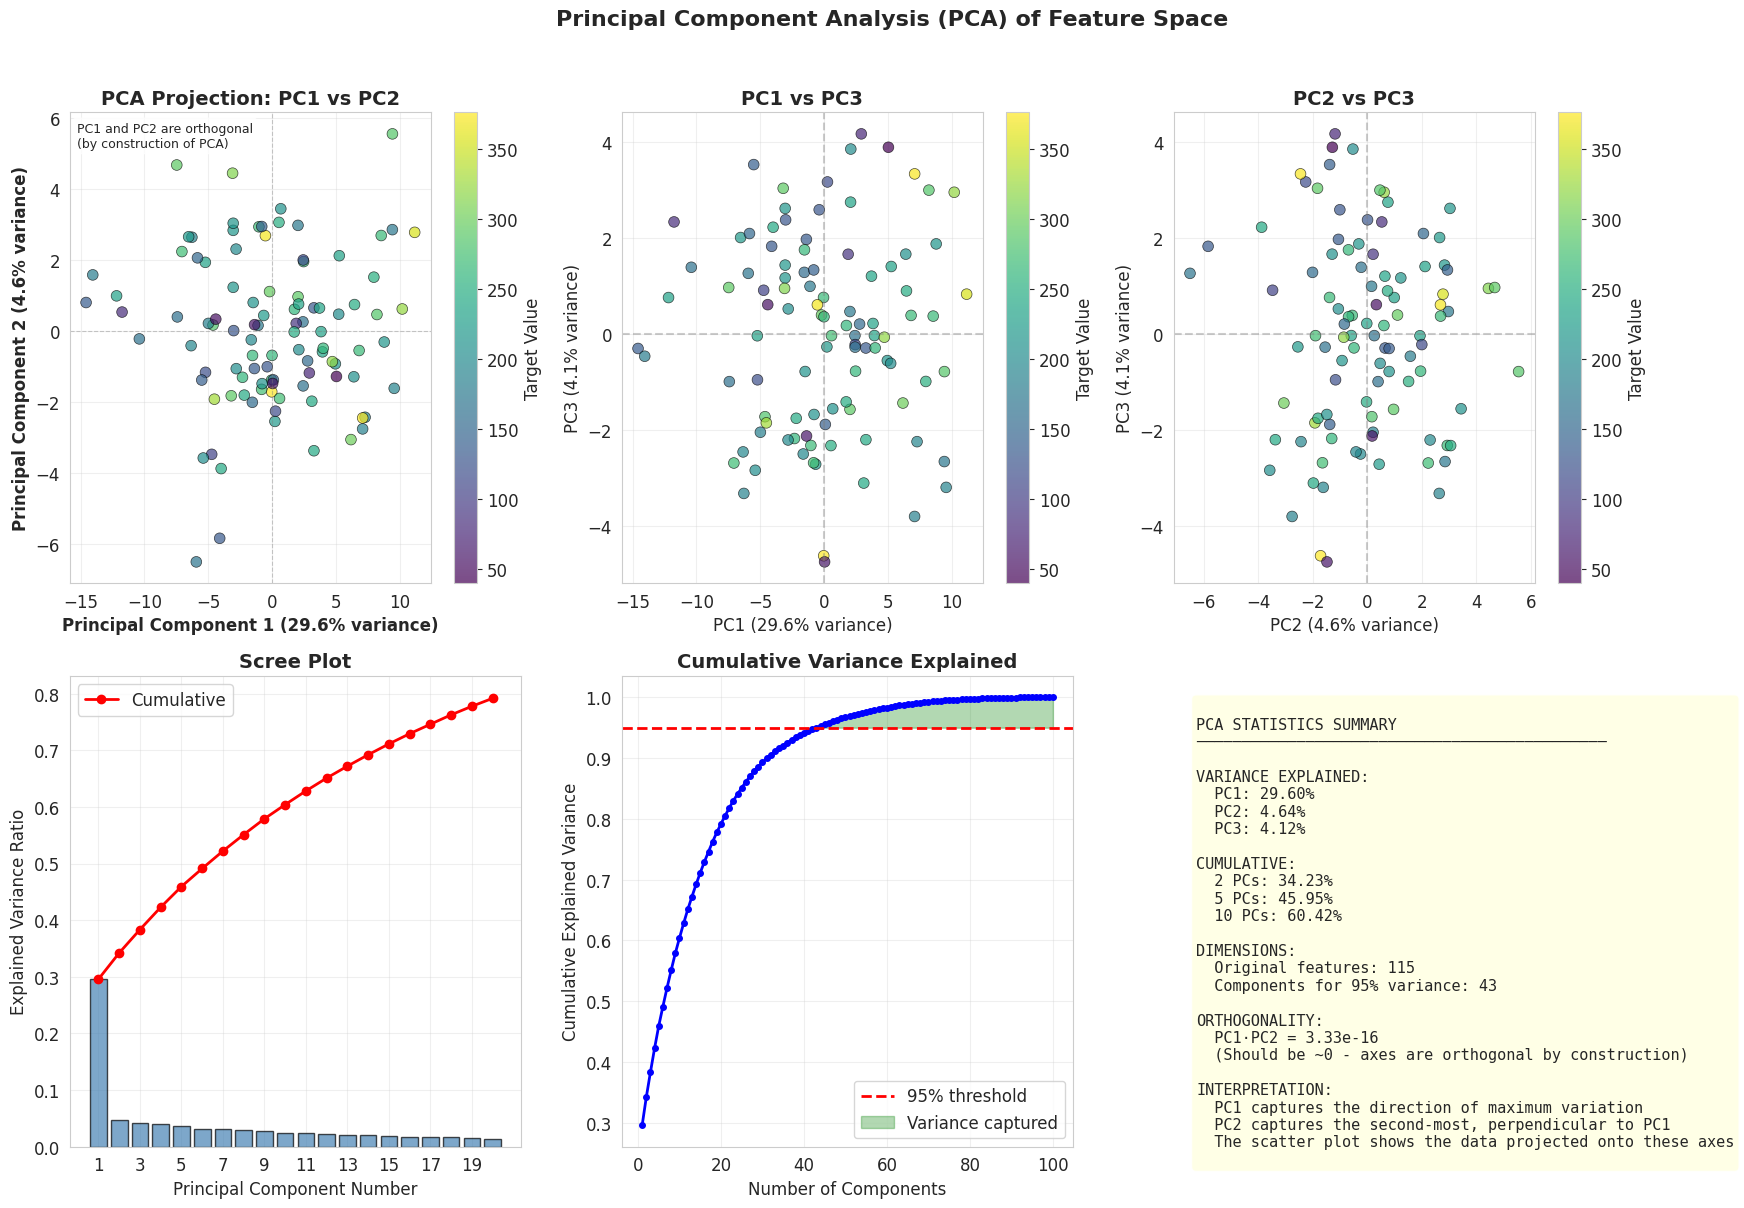

In [50]:
# PCA visualisation correction
print("\n4. Creating PCA analysis visualization...")

# Preprocess and apply PCA
preprocessor_scaled = ColumnTransformer([
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), num_cols),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore'))
    ]), cat_cols)
])

X_scaled = preprocessor_scaled.fit_transform(X_train)
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Create comprehensive PCA figure
fig = plt.figure(figsize=(18, 12))

# ===== PLOT 1: MAIN PCA SCATTER PLOT (PC1 vs PC2) =====
ax1 = plt.subplot(2, 3, 1)

# Scatter plot - points colored by target value
scatter = ax1.scatter(X_pca[:, 0], X_pca[:, 1],
                      c=y_train, cmap='viridis',
                      alpha=0.7, edgecolors='black', linewidth=0.5, s=60)
plt.colorbar(scatter, ax=ax1, label='Target Value')

# Axis labels with variance explained
ax1.set_xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]:.1%} variance)',
               fontsize=12, fontweight='bold')
ax1.set_ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]:.1%} variance)',
               fontsize=12, fontweight='bold')
ax1.set_title('PCA Projection: PC1 vs PC2', fontsize=14, fontweight='bold')

# Add grid and reference lines
ax1.axhline(y=0, color='gray', linestyle='--', alpha=0.4, linewidth=0.8)
ax1.axvline(x=0, color='gray', linestyle='--', alpha=0.4, linewidth=0.8)
ax1.grid(True, alpha=0.3)

# Add annotation about orthogonality (since axes are orthogonal by definition)
ax1.text(0.02, 0.98, f'PC1 and PC2 are orthogonal\n(by construction of PCA)',
         transform=ax1.transAxes, fontsize=9,
         verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

# ===== PLOT 2: PC1 vs PC3 =====
ax2 = plt.subplot(2, 3, 2)
scatter2 = ax2.scatter(X_pca[:, 0], X_pca[:, 2],
                       c=y_train, cmap='viridis',
                       alpha=0.7, edgecolors='black', linewidth=0.5, s=60)
plt.colorbar(scatter2, ax=ax2, label='Target Value')
ax2.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)', fontsize=12)
ax2.set_ylabel(f'PC3 ({pca.explained_variance_ratio_[2]:.1%} variance)', fontsize=12)
ax2.set_title('PC1 vs PC3', fontsize=14, fontweight='bold')
ax2.axhline(y=0, color='gray', linestyle='--', alpha=0.4)
ax2.axvline(x=0, color='gray', linestyle='--', alpha=0.4)
ax2.grid(True, alpha=0.3)

# ===== PLOT 3: PC2 vs PC3 =====
ax3 = plt.subplot(2, 3, 3)
scatter3 = ax3.scatter(X_pca[:, 1], X_pca[:, 2],
                       c=y_train, cmap='viridis',
                       alpha=0.7, edgecolors='black', linewidth=0.5, s=60)
plt.colorbar(scatter3, ax=ax3, label='Target Value')
ax3.set_xlabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)', fontsize=12)
ax3.set_ylabel(f'PC3 ({pca.explained_variance_ratio_[2]:.1%} variance)', fontsize=12)
ax3.set_title('PC2 vs PC3', fontsize=14, fontweight='bold')
ax3.axhline(y=0, color='gray', linestyle='--', alpha=0.4)
ax3.axvline(x=0, color='gray', linestyle='--', alpha=0.4)
ax3.grid(True, alpha=0.3)

# ===== PLOT 4: Scree Plot (Explained Variance) =====
ax4 = plt.subplot(2, 3, 4)
components = np.arange(1, min(21, len(pca.explained_variance_ratio_) + 1))
bars = ax4.bar(components, pca.explained_variance_ratio_[:20],
               alpha=0.7, color='steelblue', edgecolor='black')
ax4.plot(components, np.cumsum(pca.explained_variance_ratio_[:20]),
         'ro-', label='Cumulative', linewidth=2, markersize=6)
ax4.set_xlabel('Principal Component Number', fontsize=12)
ax4.set_ylabel('Explained Variance Ratio', fontsize=12)
ax4.set_title('Scree Plot', fontsize=14, fontweight='bold')
ax4.legend()
ax4.grid(True, alpha=0.3)
ax4.set_xticks(components[::2])

# ===== PLOT 5: Cumulative Variance =====
ax5 = plt.subplot(2, 3, 5)
cumulative_var = np.cumsum(pca.explained_variance_ratio_)
ax5.plot(range(1, len(cumulative_var) + 1), cumulative_var,
         'b-', linewidth=2, marker='o', markersize=4)
ax5.axhline(y=0.95, color='r', linestyle='--', linewidth=2, label='95% threshold')
ax5.fill_between(range(1, len(cumulative_var) + 1), cumulative_var, 0.95,
                  where=(cumulative_var >= 0.95), alpha=0.3, color='green',
                  label='Variance captured')
ax5.set_xlabel('Number of Components', fontsize=12)
ax5.set_ylabel('Cumulative Explained Variance', fontsize=12)
ax5.set_title('Cumulative Variance Explained', fontsize=14, fontweight='bold')
ax5.grid(True, alpha=0.3)
ax5.legend()

# ===== PLOT 6: PCA Statistics Summary =====
ax6 = plt.subplot(2, 3, 6)
ax6.axis('off')

# Calculate components needed for 95% variance
n_95 = np.argmax(np.cumsum(pca.explained_variance_ratio_) >= 0.95) + 1

pca_text = f"""
PCA STATISTICS SUMMARY
─────────────────────────────────────────────

VARIANCE EXPLAINED:
  PC1: {pca.explained_variance_ratio_[0]:.2%}
  PC2: {pca.explained_variance_ratio_[1]:.2%}
  PC3: {pca.explained_variance_ratio_[2]:.2%}

CUMULATIVE:
  2 PCs: {np.sum(pca.explained_variance_ratio_[:2]):.2%}
  5 PCs: {np.sum(pca.explained_variance_ratio_[:5]):.2%}
  10 PCs: {np.sum(pca.explained_variance_ratio_[:10]):.2%}

DIMENSIONS:
  Original features: {X_scaled.shape[1]}
  Components for 95% variance: {n_95}

ORTHOGONALITY:
  PC1·PC2 = {np.dot(pca.components_[0], pca.components_[1]):.2e}
  (Should be ~0 - axes are orthogonal by construction)

INTERPRETATION:
  PC1 captures the direction of maximum variation
  PC2 captures the second-most, perpendicular to PC1
  The scatter plot shows the data projected onto these axes
"""

ax6.text(0.05, 0.95, pca_text, fontsize=11,
         verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.suptitle('Principal Component Analysis (PCA) of Feature Space',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('pca_analysis.png', dpi=300, bbox_inches='tight')
plt.show()


5. Creating feature correlation heatmap...
X_scaled shape: (100, 115)
Number of feature names: 115


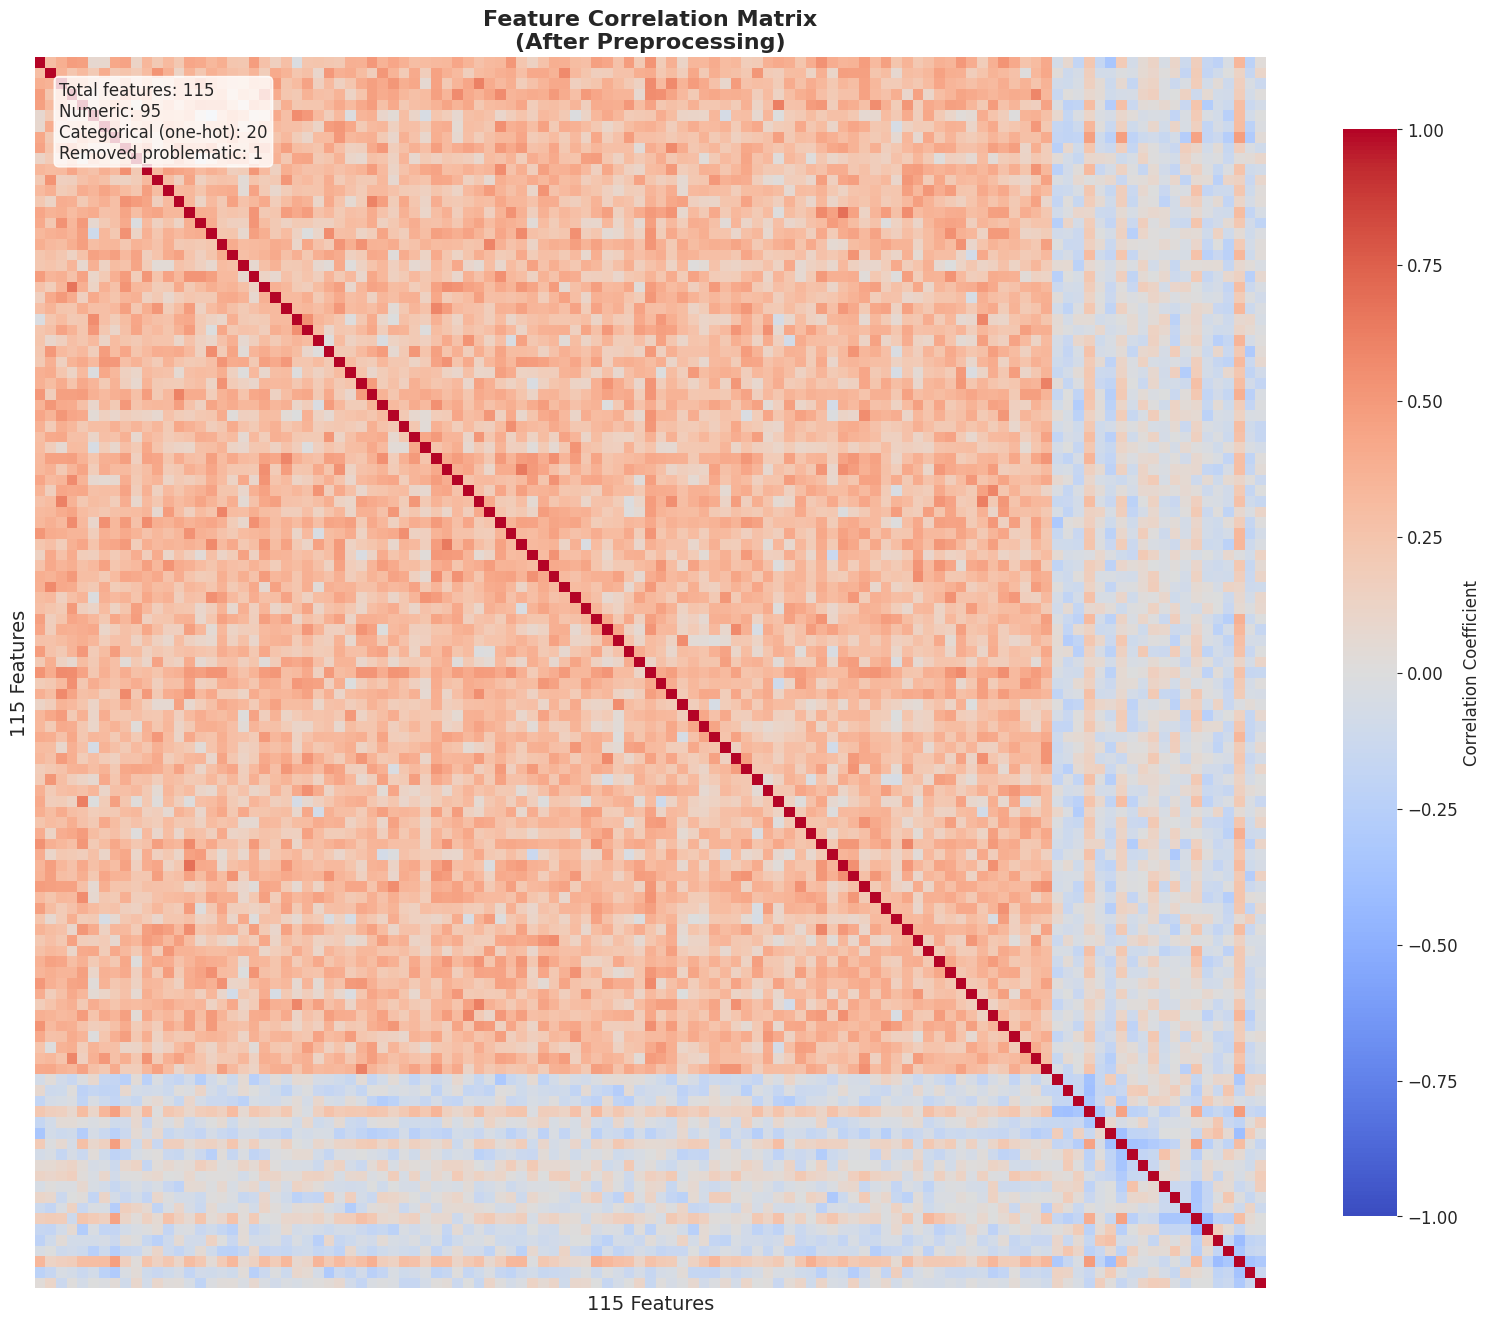

In [51]:
# Correlation heatmap
print("\n5. Creating feature correlation heatmap...")

# Get feature names
feature_names = num_cols.copy()
encoder = preprocessor_scaled.named_transformers_['cat'].named_steps['encoder']
cat_feature_names = encoder.get_feature_names_out(cat_cols)
feature_names.extend(cat_feature_names)

print(f"X_scaled shape: {X_scaled.shape}")
print(f"Number of feature names: {len(feature_names)}")

# Create correlation matrix
corr_matrix = pd.DataFrame(X_scaled, columns=feature_names).corr()

# Create heatmap
fig, ax = plt.subplots(figsize=(16, 14))

# Plot heatmap
heatmap = sns.heatmap(corr_matrix,
                      cmap='coolwarm',
                      center=0,
                      vmin=-1,
                      vmax=1,
                      square=True,
                      cbar_kws={'label': 'Correlation Coefficient', 'shrink': 0.8},
                      xticklabels=False,
                      yticklabels=False,
                      ax=ax)

# Set titles and labels
ax.set_title('Feature Correlation Matrix\n(After Preprocessing)', fontsize=16, fontweight='bold')
ax.set_xlabel(f'{len(feature_names)} Features', fontsize=14)
ax.set_ylabel(f'{len(feature_names)} Features', fontsize=14)

# Add annotation about feature types
removed_count = len(cat_cols_to_drop) + len(num_cols_to_drop)
ax.text(0.02, 0.98,
        f'Total features: {len(feature_names)}\n'
        f'Numeric: {len(num_cols)}\n'
        f'Categorical (one-hot): {len(cat_feature_names)}\n'
        f'Removed problematic: {removed_count}',
        transform=ax.transAxes,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8),
        fontsize=12)

plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()


6. Creating correlation statistics visualization...


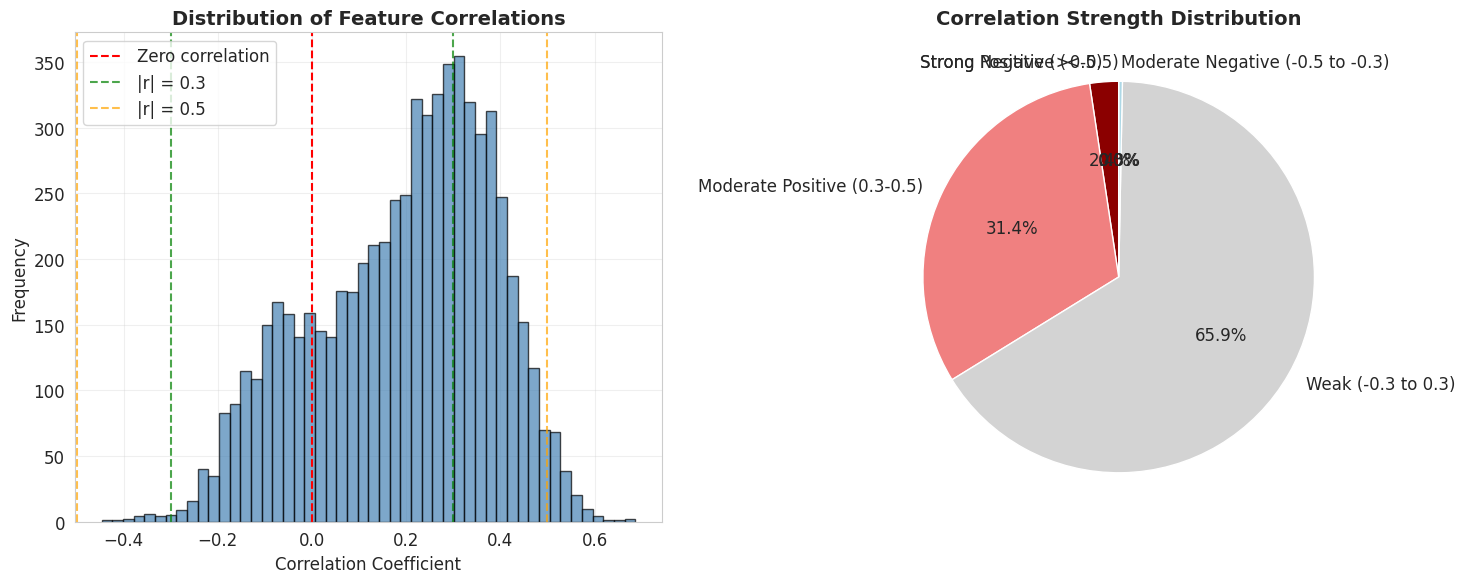

In [38]:
# Correlation statistics visualization
print("\n6. Creating correlation statistics visualization...")
corr_values = corr_matrix.values[np.triu_indices_from(corr_matrix.values, k=1)]
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Histogram of correlations
ax1 = axes[0]
ax1.hist(corr_values, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
ax1.axvline(0, color='red', linestyle='--', label='Zero correlation')
ax1.axvline(0.3, color='green', linestyle='--', alpha=0.7, label='|r| = 0.3')
ax1.axvline(-0.3, color='green', linestyle='--', alpha=0.7)
ax1.axvline(0.5, color='orange', linestyle='--', alpha=0.7, label='|r| = 0.5')
ax1.axvline(-0.5, color='orange', linestyle='--', alpha=0.7)
ax1.set_xlabel('Correlation Coefficient')
ax1.set_ylabel('Frequency')
ax1.set_title('Distribution of Feature Correlations', fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Correlation categories as pie chart
ax2 = axes[1]
categories = [
    'Strong Positive (>0.5)',
    'Moderate Positive (0.3-0.5)',
    'Weak (-0.3 to 0.3)',
    'Moderate Negative (-0.5 to -0.3)',
    'Strong Negative (<-0.5)'
]
counts = [
    np.sum(corr_values > 0.5),
    np.sum((corr_values > 0.3) & (corr_values <= 0.5)),
    np.sum(np.abs(corr_values) <= 0.3),
    np.sum((corr_values < -0.3) & (corr_values >= -0.5)),
    np.sum(corr_values < -0.5)
]
colors = ['darkred', 'lightcoral', 'lightgray', 'lightblue', 'darkblue']

wedges, texts, autotexts = ax2.pie(counts, labels=categories, colors=colors,
                                     autopct='%1.1f%%', startangle=90)
ax2.set_title('Correlation Strength Distribution', fontweight='bold')

plt.tight_layout()
plt.savefig('correlation_statistics.png', dpi=300, bbox_inches='tight')
plt.show()

In [39]:
# Pipeline creation
def create_model_pipeline(model_name, **params):

    if model_name in ["lasso","ridge","elasticnet","pcr"]:
        preprocessor = preprocessor_scaled
    elif model_name == "randomforest":
        preprocessor = preprocessor_unscaled
    else:
        raise ValueError("Unknown model")

    if model_name == "lasso":
        model = Lasso(**params)

    elif model_name == "ridge":
        model = Ridge(**params)

    elif model_name == "elasticnet":
        model = ElasticNet(**params)

    elif model_name == "randomforest":
        model = RandomForestRegressor(**params)

    elif model_name == "pcr":
        n_components = params.get("n_components",10)

        model = Pipeline([("pca", PCA(n_components=n_components)), ("regression", LinearRegression())])

    pipeline = Pipeline([("preprocessing", preprocessor), ("model", model)])
    return pipeline

In [40]:
# Example pipelines
lasso_pipe = create_model_pipeline("lasso", alpha=1.0)

ridge_pipe = create_model_pipeline("ridge", alpha=1.0)

elastic_pipe = create_model_pipeline("elasticnet", alpha=0.1, l1_ratio=0.5)

rf_pipe = create_model_pipeline("randomforest", n_estimators=100, random_state=42)

pcr_pipe = create_model_pipeline("pcr", n_components=10)

In [41]:
# Rough pipeline test on small sample
X_sample = X_train.head(20)
y_sample = y_train.head(20)

for pipe in [lasso_pipe, ridge_pipe, elastic_pipe, rf_pipe, pcr_pipe]:

    pipe.fit(X_sample, y_sample)

    preds = pipe.predict(X_sample)

    mse = np.mean((y_sample - preds)**2)

    print("Test MSE:", mse)

Test MSE: 14.764108393548502
Test MSE: 0.8694678078210367
Test MSE: 1.367758504092898
Test MSE: 594.2711704149713
Test MSE: 1238.0452096758447
